In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('wnba_player_and_team_stats_2003-2025.csv', low_memory=False)
df.head()

,Unnamed: 0,game_id,season,season_type,game_date,game_date_time,athlete_id,athlete_display_name,team_id,team_name,...,opponent_team_name,opponent_team_location,opponent_team_display_name,opponent_team_abbreviation,opponent_team_logo,opponent_team_color,opponent_team_alternate_color,opponent_team_score,athlete_headshot_href,reason
0,1,230916003,2003,3,2003-09-16,2003-09-16 20:00:00,9,DeLisha Milton-Jones,6,Sparks,...,Shock,Detroit,Detroit Shock,TUL,NaN,11213e,c5d646,83,NaN,NaN
1,2,230916003,2003,3,2003-09-16,2003-09-16 20:00:00,3,Tamecka Dixon,6,Sparks,...,Shock,Detroit,Detroit Shock,TUL,NaN,11213e,c5d646,83,NaN,NaN
2,3,230916003,2003,3,2003-09-16,2003-09-16 20:00:00,6,Lisa Leslie,6,Sparks,...,Shock,Detroit,Detroit Shock,TUL,NaN,11213e,c5d646,83,NaN,NaN
3,4,230916003,2003,3,2003-09-16,2003-09-16 20:00:00,7,Mwadi Mabika,6,Sparks,...,Shock,Detroit,Detroit Shock,TUL,NaN,11213e,c5d646,83,NaN,NaN
4,5,230916003,2003,3,2003-09-16,2003-09-16 20:00:00,10,Nikki Teasley,6,Sparks,...,Shock,Detroit,Detroit Shock,TUL,NaN,11213e,c5d646,83,NaN,NaN


In [11]:
df.shape

(120505, 58)

In [12]:
df.columns.tolist()

['Unnamed: 0',
 'game_id',
 'season',
 'season_type',
 'game_date',
 'game_date_time',
 'athlete_id',
 'athlete_display_name',
 'team_id',
 'team_name',
 'team_location',
 'team_short_display_name',
 'minutes',
 'field_goals_made',
 'field_goals_attempted',
 'three_point_field_goals_made',
 'three_point_field_goals_attempted',
 'free_throws_made',
 'free_throws_attempted',
 'offensive_rebounds',
 'defensive_rebounds',
 'rebounds',
 'assists',
 'steals',
 'blocks',
 'turnovers',
 'fouls',
 'plus_minus',
 'points',
 'starter',
 'ejected',
 'did_not_play',
 'active',
 'athlete_jersey',
 'athlete_short_name',
 'athlete_position_name',
 'athlete_position_abbreviation',
 'team_display_name',
 'team_uid',
 'team_slug',
 'team_logo',
 'team_abbreviation',
 'team_color',
 'team_alternate_color',
 'home_away',
 'team_winner',
 'team_score',
 'opponent_team_id',
 'opponent_team_name',
 'opponent_team_location',
 'opponent_team_display_name',
 'opponent_team_abbreviation',
 'opponent_team_logo',
 

In [13]:
df['athlete_display_name'].value_counts().head(10)

athlete_display_name
Diana Taurasi           742
Sue Bird                723
DeWanna Bonner          640
Lindsay Whalen          590
Rebekkah Brunson        589
Candace Parker          582
Alana Beard             578
Courtney Vandersloot    570
Candice Dupree          560
Seimone Augustus        557
Name: count, dtype: int64

In [14]:
df['season'].value_counts().sort_index()

season
2003    4279
2004    4694
2005    5079
2006    6076
2007    5919
2008    6245
2009    5348
2010    4831
2011    4953
2012    4889
2013    4961
2014    5228
2015    5379
2016    5176
2017    5183
2018    5187
2019    5211
2020    3544
2021    4626
2022    5307
2023    5796
2024    5929
2025    6665
Name: count, dtype: int64

In [ ]:
df.groupby('season')['team_score'].mean()

season
2003    68.046039
2004    66.784832
2005    67.448120
2006    75.195853
2007    76.972462
2008    75.703923
2009    79.014024
2010    80.586628
2011    77.464971
2012    77.543874
2013    75.377545
2014    77.533665
2015    75.246514
2016    82.033617
2017    81.432375
2018    83.014845
2019    79.537709
2020    82.649549
2021    80.842629
2022    82.319013
2023    82.673395
2024    81.700287
2025    81.839910
Name: team_score, dtype: float64

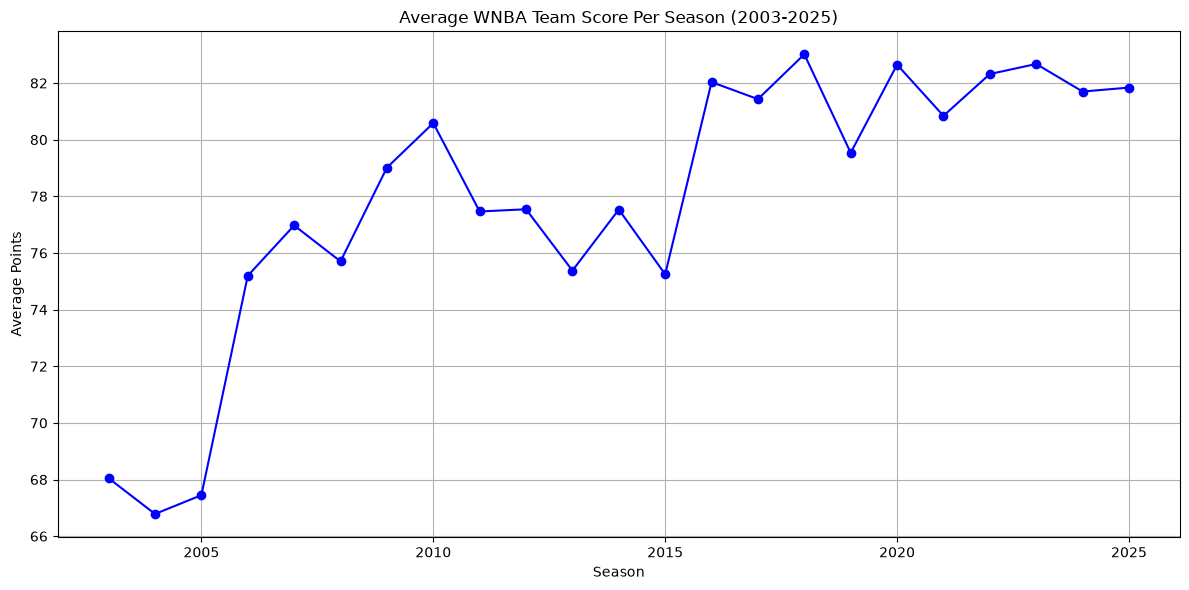

In [15]:
import matplotlib.pyplot as plt

season_scores = df.groupby('season')['team_score'].mean()

plt.figure(figsize=(12,6))
plt.plot(season_scores.index, season_scores.values, marker='o', color='blue')
plt.title('Average WNBA Team Score Per Season (2003-2025)')
plt.xlabel('Season')
plt.ylabel('Average Points')
plt.grid(True)
plt.tight_layout()
plt.show()

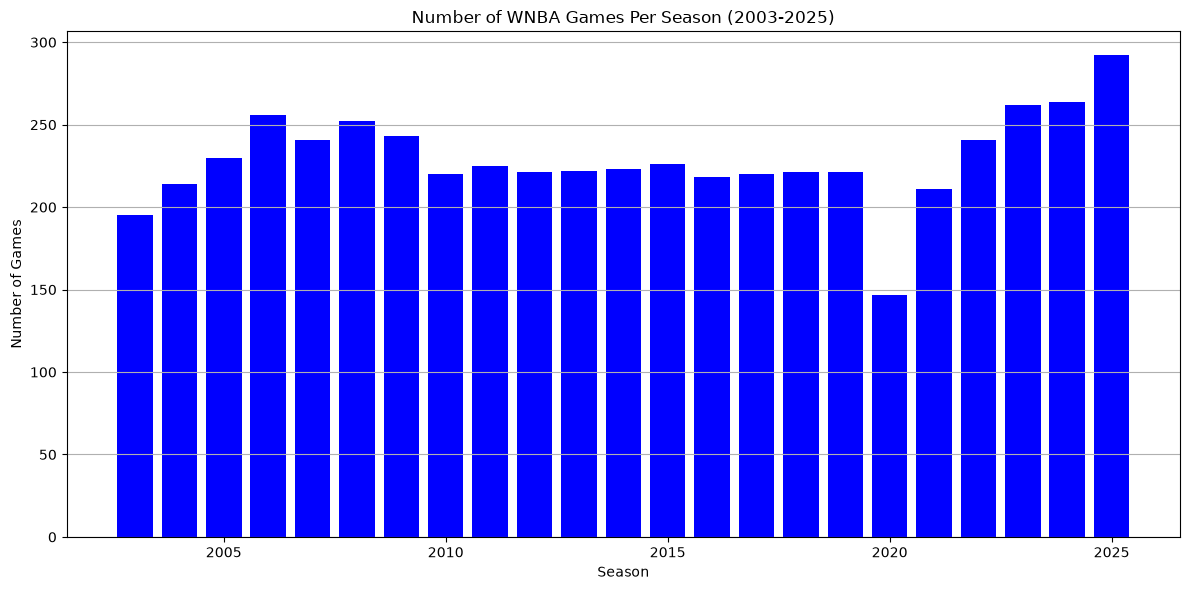

In [17]:
season_games = df.groupby('season')['game_id'].nunique()

plt.figure(figsize=(12,6))
plt.bar(season_games.index, season_games.values, color='blue')
plt.title('Number of WNBA Games Per Season (2003-2025)')
plt.xlabel('Season')
plt.ylabel('Number of Games')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [18]:
# drop unnecessary columns 
columns_to_drop = [
    'athlete_headshot_href', 'team_logo', 'opponent_team_logo',
    'team_uid', 'team_slug', 'team_color', 'team_alternate_color',
    'opponent_team_color', 'opponent_team_alternate_color',
    'Unnamed: 0', 'reason', 'athlete_jersey', 'athlete_position_abbreviation'
]
df = df.drop(columns=columns_to_drop)

# fix plus_minus from string to number
df['plus_minus'] = pd.to_numeric(df['plus_minus'], errors='coerce')

# filter to only rows where player actually played
df_played = df[df['did_not_play'] == False].copy()

# drop remaining missing values in key stat columns
stat_columns = ['minutes', 'points', 'rebounds', 'assists', 
                'steals', 'blocks', 'turnovers', 'fouls',
                'field_goals_made', 'field_goals_attempted']
df_clean = df_played.dropna(subset=stat_columns)

# Step 5 - Check the result
print(f"Original rows: {len(df)}")
print(f"Clean rows: {len(df_clean)}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

Original rows: 120505
Clean rows: 101343
Missing values remaining: 0


In [19]:
df_clean['result'] = df_clean['team_winner'].astype(int)
df_clean['result'].value_counts()

result
0    50746
1    50597
Name: count, dtype: int64

In [20]:
# Define your feature columns (what the model learns from)
features = [
    'minutes', 'points', 'rebounds', 'assists', 
    'steals', 'blocks', 'turnovers', 'fouls',
    'field_goals_made', 'field_goals_attempted',
    'three_point_field_goals_made', 'three_point_field_goals_attempted',
    'free_throws_made', 'free_throws_attempted',
    'offensive_rebounds', 'defensive_rebounds', 'plus_minus'
]

# Define X (features) and y (target)
X = df_clean[features]
y = df_clean['result']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (101343, 17)
Target shape: (101343,)
